<a href="https://colab.research.google.com/github/Vemas144/PCVK_Ganjil_2025/blob/main/Week6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MODUL 6 – Histogram, Histogram Equalization, Dithering
Nama: Vemas Bagus Fermanda

Kelas: 3A

NIM: 2341720137

TUGAS PRAKTIKUM

1.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


2.

In [2]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob

3.

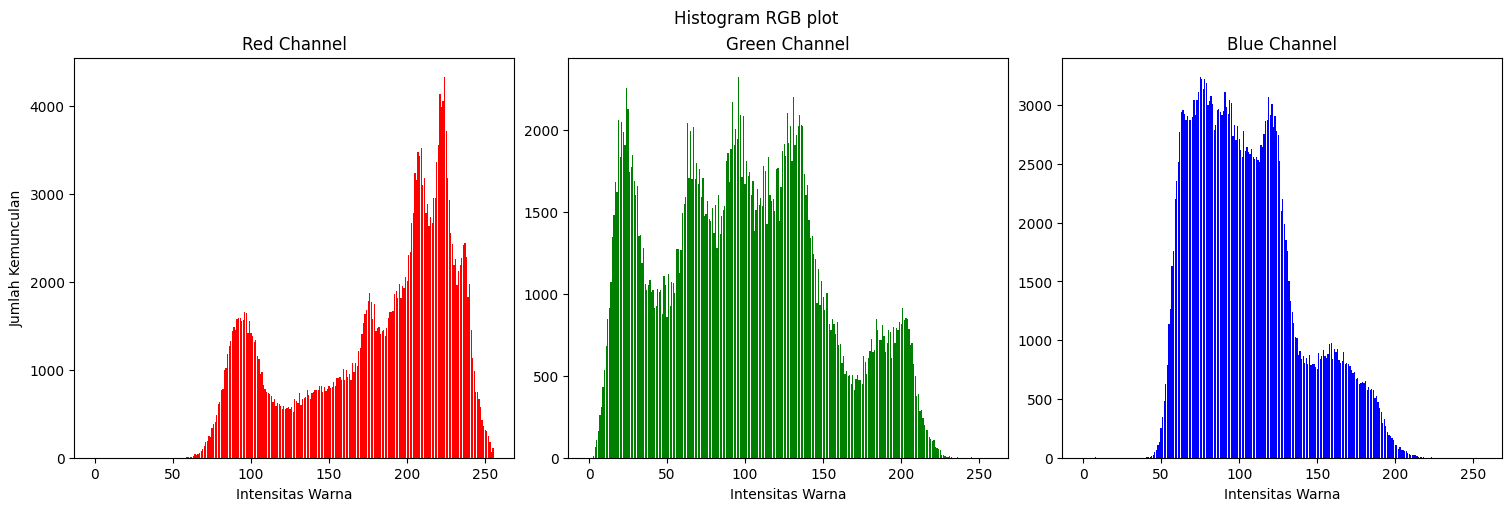

In [9]:
img = cv.imread('/content/drive/MyDrive/images/Lenna.png')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)  # ubah BGR ke RGB

# Pisahkan channel R, G, B
R, G, B = img[:,:,0], img[:,:,1], img[:,:,2]

# Hitung histogram manual untuk tiap channel
hist_r = np.zeros(256, dtype=int)
hist_g = np.zeros(256, dtype=int)
hist_b = np.zeros(256, dtype=int)

for y in range(img.shape[0]):
    for x in range(img.shape[1]):
        hist_r[R[y,x]] += 1
        hist_g[G[y,x]] += 1
        hist_b[B[y,x]] += 1

# Tampilkan histogram RGB
plt.figure(figsize=(15,5), constrained_layout=True)
plt.suptitle("Histogram RGB plot")

plt.subplot(1,3,1)
plt.bar(np.arange(256), hist_r, color='red')
plt.title("Red Channel")
plt.xlabel("Intensitas Warna")
plt.ylabel("Jumlah Kemunculan")
# plt.ylim(0, 2500) # Set y-axis limit

plt.subplot(1,3,2)
plt.bar(np.arange(256), hist_g, color='green')
plt.title("Green Channel")
plt.xlabel("Intensitas Warna")
# plt.ylim(0, 2500) # Set y-axis limit

plt.subplot(1,3,3)
plt.bar(np.arange(256), hist_b, color='blue')
plt.title("Blue Channel")
plt.xlabel("Intensitas Warna")
# plt.ylim(0, 2500) # Set y-axis limit

plt.show()

3, buatlah histogram citra yang sama akan tetapi
menggunakan library yang dimiliki oleh NumPy

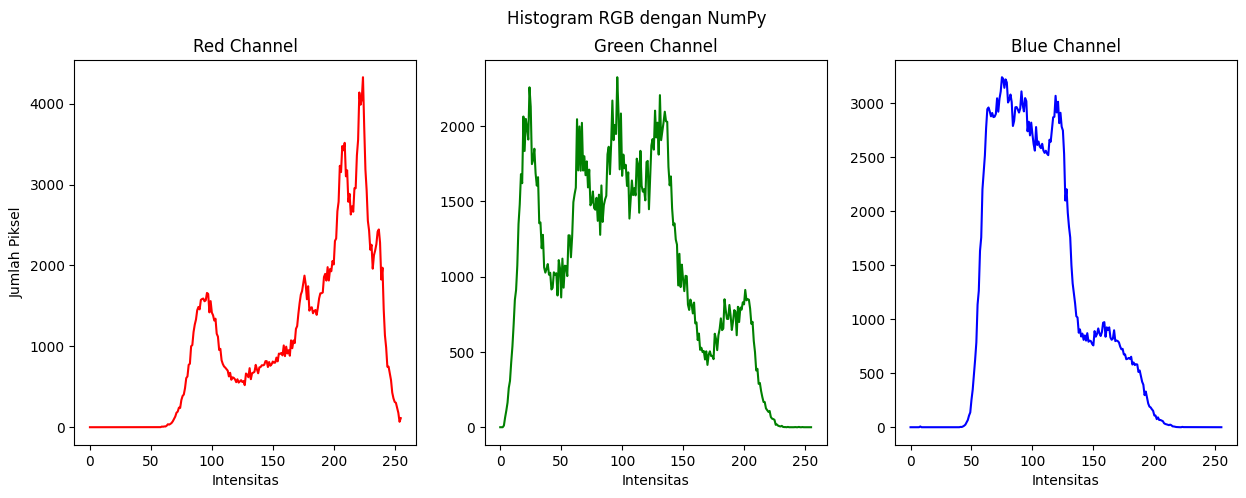

In [11]:
# Baca gambar berwarna
img = cv.imread('/content/drive/MyDrive/images/Lenna.png')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Pisahkan channel R, G, B
R, G, B = img[:,:,0], img[:,:,1], img[:,:,2]

# Hitung histogram dengan NumPy
hist_r, bins_r = np.histogram(R, bins=256, range=(0,256))
hist_g, bins_g = np.histogram(G, bins=256, range=(0,256))
hist_b, bins_b = np.histogram(B, bins=256, range=(0,256))

# Tampilkan hasil histogram
plt.figure(figsize=(15,5))
plt.suptitle("Histogram RGB dengan NumPy")

plt.subplot(1,3,1)
plt.plot(hist_r, color='red')
plt.title("Red Channel")
plt.xlabel("Intensitas")
plt.ylabel("Jumlah Piksel")

plt.subplot(1,3,2)
plt.plot(hist_g, color='green')
plt.title("Green Channel")
plt.xlabel("Intensitas")

plt.subplot(1,3,3)
plt.plot(hist_b, color='blue')
plt.title("Blue Channel")
plt.xlabel("Intensitas")

plt.show()

Hasil histogram manual dan histogram menggunakan numpy.histogram() memberikan output yang sama hanya berbeda pada tampilan visualisasi, karena keduanya sama-sama menghitung distribusi jumlah piksel pada tiap tingkat intensitas. Perbedaannya hanya pada cara implementasi: manual dilakukan dengan perulangan, sedangkan NumPy lebih efisien dengan fungsi bawaan.

5. Buatlah histogram citra seperti output histogram equalization

In [ ]:
# Baca gambar berwarna
img = cv.imread('/content/drive/MyDrive/images/Lenna.png')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Hitung frekuensi tiap intensitas secara manual
hist = np.zeros(256, dtype=int)
for y in range(img.shape[0]):
    for x in range(img.shape[1]):
        nilai = img[y, x]      # ambil nilai piksel
        hist[nilai] += 1       # tambah frekuensi di intensitas tsb

